<center>
<img src="https://supportvectors.ai/logo-poster-transparent.png" width=400px style="opacity:0.8">
</center>

In [1]:
%run supportvectors-common.ipynb


<div style="color:#aaa;font-size:8pt">
<hr/>
&copy; SupportVectors. All rights reserved. <blockquote>This notebook is the intellectual property of SupportVectors, and part of its training material. 
Only the participants in SupportVectors workshops are allowed to study the notebooks for educational purposes currently, but is prohibited from copying or using it for any other purposes without written permission.

<b> These notebooks are chapters and sections from Asif Qamar's textbook that he is writing on Data Science. So we request you to not circulate the material to others.</b>
 </blockquote>
 <hr/>
</div>



## Visualizing ViT attention maps

In [2]:
image_path = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Cat_August_2010-4.jpg/500px-Cat_August_2010-4.jpg"

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps") if torch.backends.mps.is_available() else device

In [4]:
from transformers import ViTForImageClassification, ViTImageProcessor
from svlearn_vlu.vit_attention_maps import load_image


In [5]:
model_name = "google/vit-base-patch16-224-in21k"
model = ViTForImageClassification.from_pretrained(model_name).to(device)
processor = ViTImageProcessor.from_pretrained(model_name)

pixel_values, image = load_image(image_path, processor)
pixel_values = pixel_values.to(device)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
from svlearn_vlu.vit_attention_maps import get_attention_maps
layer = -1
layer_idx = layer if layer >= 0 else model.config.num_hidden_layers + layer
print(f"Extracting attention for layer {layer_idx}...")
attention_weights = get_attention_maps(model, pixel_values, layer_idx, device)

Extracting attention for layer 11...
No attentions returned; retrying on CPU...
Running encoder manually and calling target layer with eager attn...
No attentions returned; forcing eager attention...
Original implementation: sdpa


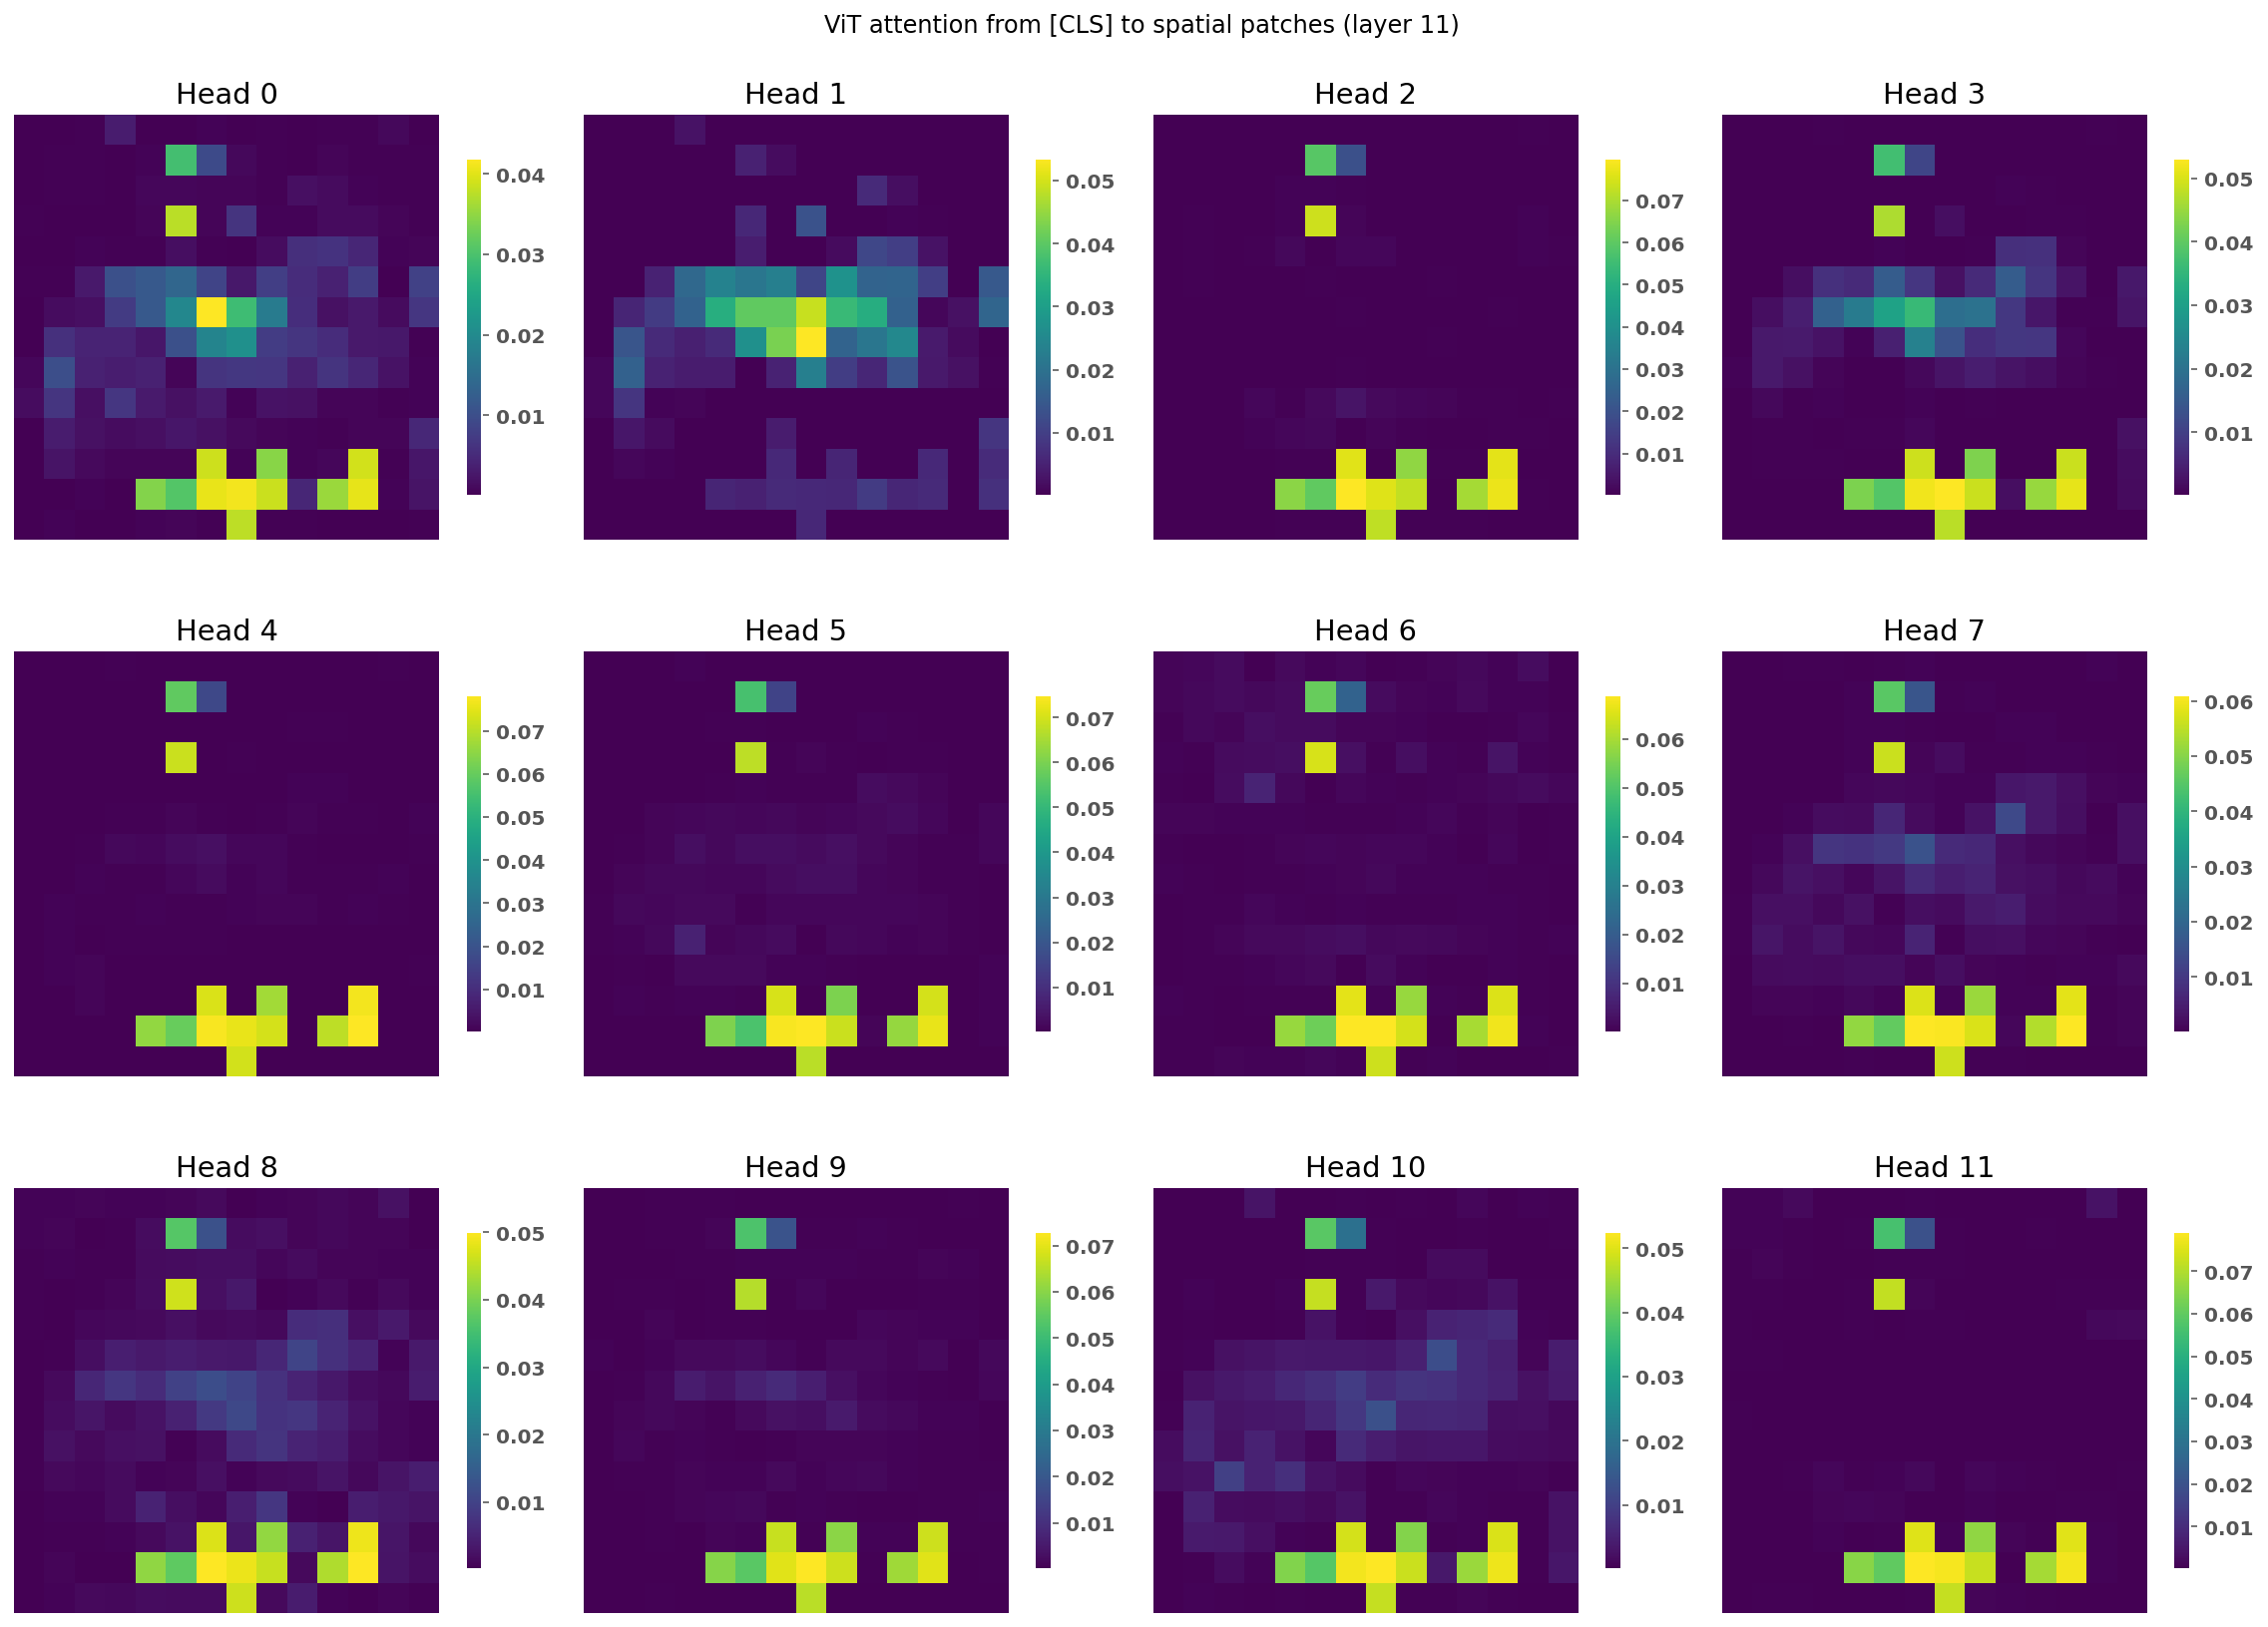

In [7]:
from svlearn_vlu.vit_attention_maps import plot_attention_heads
plot_attention_heads(
        attention_weights,
        num_heads=model.config.num_attention_heads,
        layer_idx=layer_idx,
    )

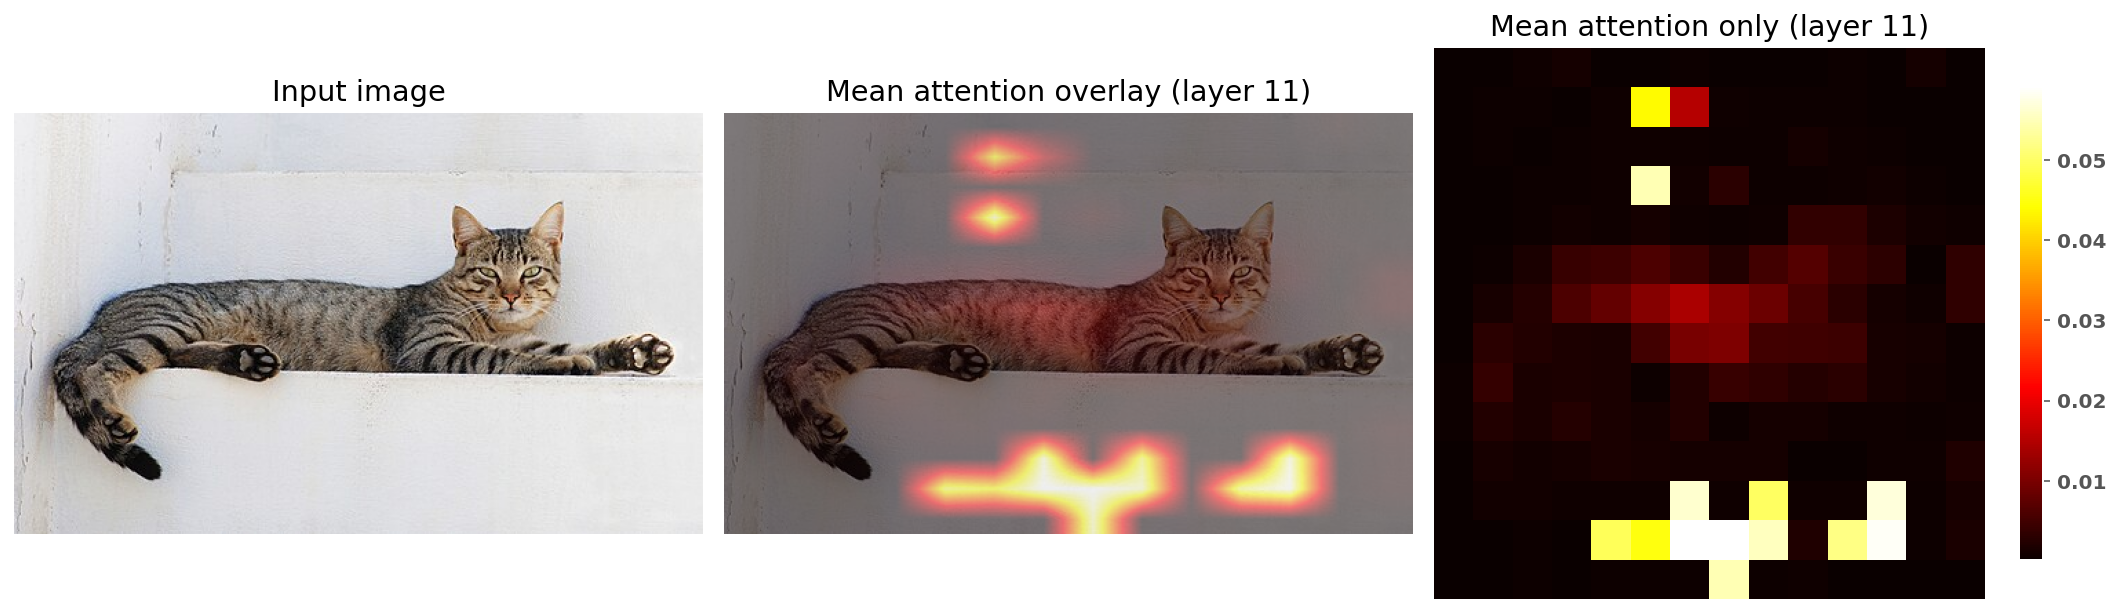

In [8]:
from svlearn_vlu.vit_attention_maps import plot_attention_overlay
plot_attention_overlay(
        attention_weights,
        image,
        layer_idx=layer_idx,
    )
